In [1]:
import contextily as cx
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

from advan_test import data
from advan_test.utils import project_root

# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

polars.config.Config

In [2]:
DATA_PATH = project_root() / "data"
CSV_PATH = DATA_PATH / "weekly-patterns-plus-sample.csv"
PARQUET_DIR_PATH = DATA_PATH / "2025-weekly-patterns-plus"
US_PATH = DATA_PATH / "us-states.json"

In [3]:
lf = data.load_weekly_patterns_plus_parquet(PARQUET_DIR_PATH).filter(pl.col("ISO_COUNTRY_CODE") == "US")
states = gpd.read_file(US_PATH)
states = states.loc[states["name"] != "Alaska"]
lf.head().collect()

BRAND,BUCKETED_DWELL_TIMES,CITY,CLOSE_DATE,DATE_RANGE_END,DATE_RANGE_START,DEVICE_TYPE,DISTANCE_FROM_HOME,FOOTPRINT_ID,ID_STORE,ISO_COUNTRY_CODE,IS_DISTRIBUTOR,LATITUDE,LOCATION_NAME,LONGITUDE,MEDIAN_DWELL,MSA_CODE,NAICS_CODE,OPEN_DATE,PERSISTENT_ID,PERSISTENT_ID_STORE,POI_CBG,POSTAL_CODE,REGION,RELATED_SAME_DAY_BRAND,RELATED_SAME_WEEK_BRAND,STREET_ADDRESS,SUB_CATEGORY,TICKER,TOP_CATEGORY,VISITOR_COUNTRY_OF_ORIGIN,VISITOR_COUNTS,VISITOR_DAYTIME_CBGS,VISITOR_HOME_AGGREGATION,VISITOR_HOME_CBGS,VISITS_BY_DAY,VISITS_BY_EACH_HOUR,VISIT_COUNTS
str,str,str,date,datetime[ms],datetime[ms],str,f64,"decimal[38,0]",str,str,bool,f64,str,f64,f64,"decimal[38,0]",str,date,str,str,str,str,str,str,str,str,str,str,str,str,"decimal[38,0]",str,str,str,str,str,"decimal[38,0]"
"""Casino Hotels""","""{""<5"":0, ""5-20"":0, ""21-60"":0,""…","""Denver""",2038-01-01,2025-01-12 00:00:00,2025-01-06 00:00:00,"""{""android"":12}""",15155.0,7208433527835943330,"""7578972""","""US""",false,39.740838,"""Casino Hotels""",-105.062875,744.0,19740,"""721120""",1970-01-01,"""A1_NAICS-721120""","""7578972""","""080590114012""","""80214""","""CO""","""{""7 Eleven"":24,""Armstrong Floo…","""{""7 Eleven"":24,""AMC"":24,""Advan…","""6001 W COLFAX AVE""","""Casino Hotels""","""NAICS-721120""","""Traveler Accommodation""","""{""US"":12}""",12,"""{""080590115521"":3,""08001009411…","""{""08001009411"":6,""04013040538""…","""{""080010094112"":5,""04013040538…","""[0,0,0,0,12,12,0]""","""[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0…",24
"""Drinking Places (Alcoholic Bev…","""{""<5"":24, ""5-20"":0, ""21-60"":0,…","""Florissant""",2038-01-01,2025-01-12 00:00:00,2025-01-06 00:00:00,"""{""android"":12,""ios"":12}""",5374.0,9212763892612346182,"""8800847""","""US""",false,38.816071,"""Drinking Places (Alcoholic Bev…",-90.280807,null,41180,"""722410""",1970-01-01,"""A1_NAICS-722410""","""8800847""","""291892109122""","""63034""","""MO""","""{""Convenience Stores"":24,""Mone…","""{""Aldi"":24,""Armstrong Flooring…","""4105 N Highway 67""","""Drinking Places (Alcoholic Bev…","""NAICS-722410""","""Drinking Places (Alcoholic Bev…","""{""US"":24}""",24,"""{""291892108082"":10,""2918921080…","""{""29189210808"":16,""29189210927…","""{""291892108082"":12,""2918921092…","""[0,0,24,0,0,0,0]""","""[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0…",24
"""Limited-Service Restaurants""","""{""<5"":24, ""5-20"":0, ""21-60"":0,…","""Bristol""",2038-01-01,2025-01-12 00:00:00,2025-01-06 00:00:00,"""{""android"":24}""",2526.0,8145589928901942432,"""8424994""","""US""",false,40.107189,"""Limited-Service Restaurants""",-74.864593,null,37980,"""722513""",1970-01-01,"""A1_NAICS-722513""","""8424994""","""420171003033""","""19007""","""PA""","""{""Convenience Stores"":24,""Adva…","""{""Brixmor Property Group"":24,""…","""803 Bath Rd""","""Limited-Service Restaurants ""","""NAICS-722513""","""Restaurants and Other Eating P…","""{""US"":24}""",24,"""{""421010349002"":16,""4201710030…","""{""42017100303"":24}""","""{""420171003031"":16,""4201710030…","""[0,0,12,0,0,12,0]""","""[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0…",24
"""Drinking Places (Alcoholic Bev…","""{""<5"":0, ""5-20"":0, ""21-60"":0,""…","""Vera town""",2038-01-01,2025-01-12 00:00:00,2025-01-06 00:00:00,"""{""android"":24}""",13879.0,8833321464446171214,"""7606198""","""US""",false,36.327137,"""Drinking Places (Alcoholic Bev…",-95.84775,1326.0,46140,"""722410""",1970-01-01,"""A1_NAICS-722410""","""7606198""","""401430058102""","""74021""","""OK""","""{""Dunlop Tires"":24,""Moneygram""…","""{""Arby's"":24,""Blue Buffalo"":24…","""11907 N Garnett Rd""","""Drinking Places (Alcoholic Bev…","""NAICS-722410""","""Drinking Places (Alcoholic Bev…","""{""US"":24}""",24,"""{""401430054031"":6,""40113940014…","""{""40143005403"":4,""40143005810""…","""{""401430058102"":3,""40143005403…","""[12,12,0,0,0,0,0]""","""[6,0,0,0,0,6,0,0,0,0,0,0,0,0,0…",24
"""Commercial Printing (except Sc…","""{""<5"":24, ""5-20"":0, ""21-60"":0,…","""Los Angeles""",2038-01-01,2025-01-12 00:00:00,2025-01-06 00:00:00,""

In [4]:
poi_metadata = (
    lf.select("ID_STORE", "LOCATION_NAME", "REGION", "ISO_COUNTRY_CODE", "LONGITUDE", "LATITUDE")
    .group_by("ID_STORE")
    .agg(pl.all().exclude("ID_STORE").first())
    .collect()
)

<Axes: xlabel='NUM_POIS', ylabel='REGION'>

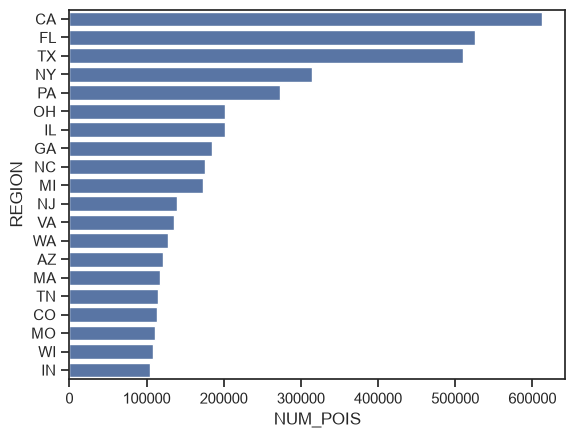

In [5]:
top_pois = (poi_metadata
    .group_by("REGION", "ISO_COUNTRY_CODE")
    .agg(pl.len().alias("NUM_POIS"))
    .sort("NUM_POIS")
    .top_k(20, by="NUM_POIS")
)
sns.barplot(top_pois, y="REGION", x="NUM_POIS")

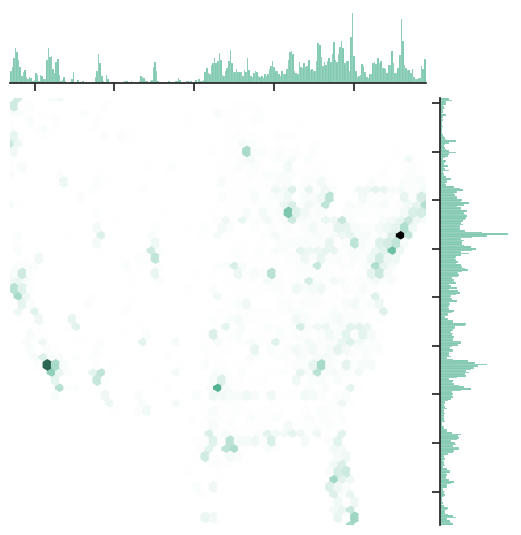

In [6]:
xcol = "LONGITUDE"
ycol = "LATITUDE"
xlim = (poi_metadata[xcol].quantile(0.01), poi_metadata[xcol].quantile(0.99))
ylim = (poi_metadata[ycol].quantile(0.01), poi_metadata[ycol].quantile(0.99))
ax_grid = sns.jointplot(
    data=poi_metadata.filter(pl.col(xcol).is_between(*xlim), pl.col(ycol).is_between(*ylim)),
    x=xcol, 
    y=ycol, 
    kind="hex",
    color="#4CB391",
    xlim=xlim,
    ylim=ylim,
)
ax_grid.ax_joint.set_axis_off()

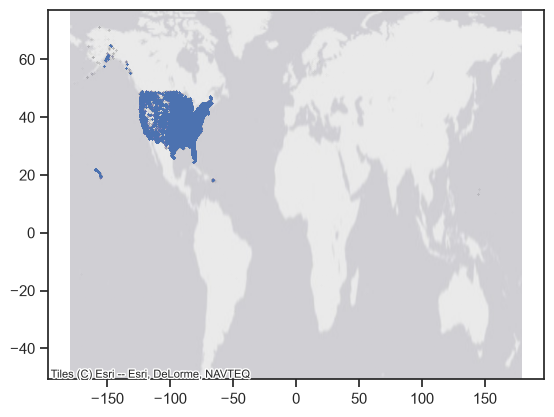

In [7]:
fig, ax = plt.subplots()
ax.scatter(poi_metadata["LONGITUDE"], poi_metadata["LATITUDE"], s=.1, alpha=.01)
minx, miny, maxx, maxy = states.total_bounds
#ax.set_xlim(minx, maxx)
#ax.set_ylim(miny, maxy)
cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.Esri.WorldGrayCanvas, zoom=1)

In [8]:
visitors_by_poi = (
    lf
        .group_by("ID_STORE", "REGION")
        .agg(pl.col("VISITOR_COUNTS").sum())
        .sort(pl.col("VISITOR_COUNTS"))
        .collect()
)

Text(0.5, 1.0, 'CCDF of POI Visitor Counts')

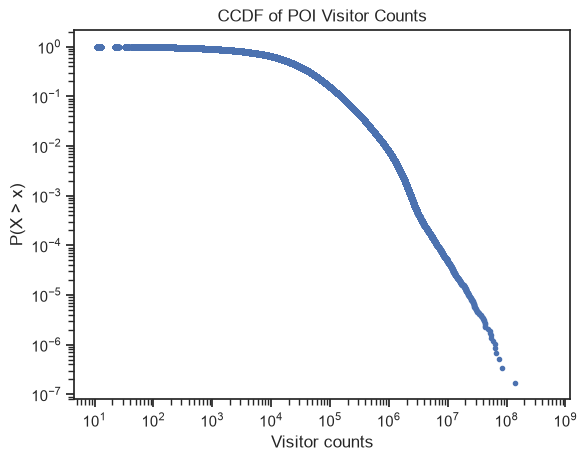

In [9]:
series = visitors_by_poi["VISITOR_COUNTS"].to_numpy()
n = len(series)
# CCDF: P(X > x) for each sorted value
# For the i-th smallest value (1-indexed), the fraction of points
# strictly greater than it is (n - i) / n
ccdf = 1.0 - (np.arange(1, n + 1) / n)

fig, ax = plt.subplots()
ax.scatter(series, ccdf, marker=".", linestyle="none")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Visitor counts")
ax.set_ylabel("P(X > x)")
ax.set_title("CCDF of POI Visitor Counts")

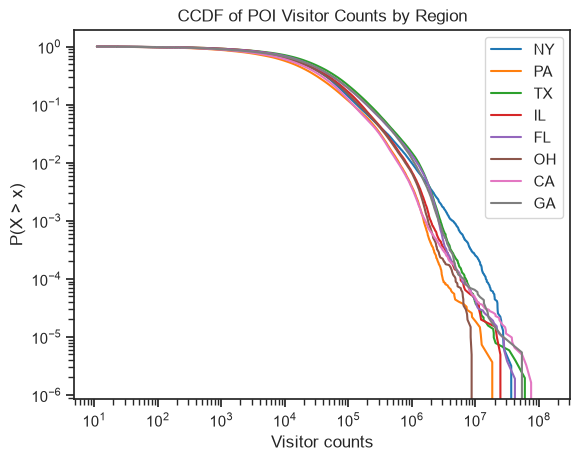

In [10]:
fig, ax = plt.subplots()
colors = list(mcolors.TABLEAU_COLORS)
region_poi_counts = visitors_by_poi.group_by("REGION").len().filter(pl.col("len") > 10_000).top_k(8, by="len")
agg = visitors_by_poi.join(region_poi_counts, on="REGION")
for i, region in enumerate(agg["REGION"].unique()):
    series = agg.filter(pl.col("REGION") == region)["VISITOR_COUNTS"].to_numpy()
    n = len(series)
    # CCDF: P(X > x) for each sorted value
    # For the i-th smallest value (1-indexed), the fraction of points
    # strictly greater than it is (n - i) / n
    ccdf = 1.0 - (np.arange(1, n + 1) / n)

    color = colors[i]
    ax.plot(series, ccdf, label=region, color=color)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Visitor counts")
    ax.set_ylabel("P(X > x)")
    ax.set_title("CCDF of POI Visitor Counts by Region")
ax.legend()

Text(0, 0.5, '#POI-weeks')

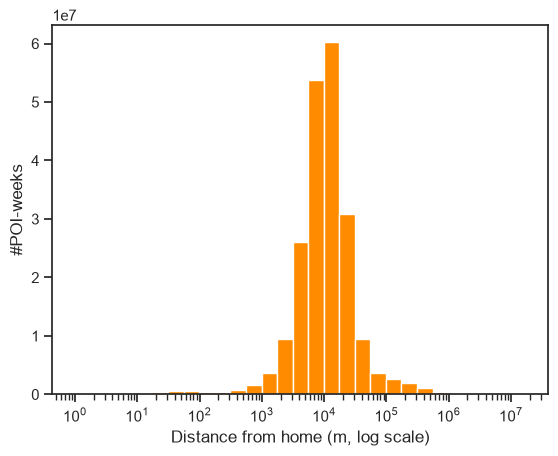

In [24]:
max_distance = None
log_scale = True

dist_lf = lf.select("DISTANCE_FROM_HOME").drop_nulls()
if max_distance is not None:
    dist_lf = dist_lf.filter(dist <= max_distance)

_, ax = plt.subplots()

if log_scale:
    dist = dist_lf.filter(pl.col("DISTANCE_FROM_HOME") > 0).collect()  # logspace needs strictly positive values
    dist_np = dist.to_numpy()
    bins = np.logspace(np.log10(dist_np.min()), np.log10(dist_np.max()), 30)
    ax.hist(dist_np, bins=bins, color="darkorange", edgecolor="white")
    ax.set_xscale("log")
    ax.set_xlabel("Distance from home (m, log scale)")
else:
    dist = dist_lf.collect()
    ax.hist(dist, bins=30, color="darkorange", edgecolor="white")
    ax.set_xlabel("Distance from home (m)")

ax.set_ylabel("#POI-weeks")
